# Poisson Solver: Comprehensive 2D Timing & Accuracy Benchmark
### Benchmarking Uniform FFT, NUDFT, NUFFT Toeplitz, and NUFFT CG (PCGLS)

This notebook executes a consolidated performance and accuracy benchmark across 2D grid matrix configurations $(N \times M)$:
$$\mathcal{M} = \{ (N, M) \mid N \in [32, 64, 128, 256], \; M \in [32, 64, 128, 256] \}$$

---

### Overarching Problem Formulation
We consider the manufactured nonseparable smooth Dirichlet Poisson problem on the unit disk $\mathbb{D} = \{ (x, y) \in \mathbb{R}^2 : x^2 + y^2 \le R^2 \}$ with $R = 1.0$:

$$u(x, y) = (1 - x^2 - y^2) \exp(x) \sin(k y)$$

with homogeneous Dirichlet boundary condition:
$$u(R, \theta) = 0 \quad \text{on } \partial \mathbb{D}$$

The exact forcing $f(x, y) = \Delta u(x, y)$ is given analytically by:
$$f(x, y) = \exp(x) \Big[ (1 - k^2)(1 - x^2 - y^2)\sin(k y) - 4(1 + x)\sin(k y) - 4k y \cos(k y) \Big]$$

---

### Evaluated Methods & Meshes:
1. **Uniform FFT** on the **Uniform Equispaced Grid**
2. **NUDFT** on the **Toeplitz Nonuniform Mesh** (Jittered Grid, $\delta = 0.25$)
3. **NUFFT Toeplitz** on the **Toeplitz Nonuniform Mesh** (Jittered Grid, $\delta = 0.25$)
4. **NUDFT** on the **CG Nonuniform Mesh** (Sine-Perturbed Grid, $a = 0.20, m = 2$)
5. **NUFFT CG (PCGLS)** on the **CG Nonuniform Mesh** (Sine-Perturbed Grid, $a = 0.20, m = 2$)


In [1]:
import os
import sys
from pathlib import Path

# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = False  # Set to True for NVIDIA GPU acceleration (cuFINUFFT / CuPy)

# Auto-detect Google Colab
IN_COLAB = 'google.colab' in sys.modules or os.environ.get('COLAB_GPU') is not None
if IN_COLAB:
    if not os.path.exists('Poisson_Solver'):
        os.system('git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git')
        if os.path.exists('NUFFTRR_Poisson'):
            os.chdir('NUFFTRR_Poisson')
    os.system('pip install -r requirements.txt -q')
    if USE_GPU:
        os.system('pip install cufinufft -q')

# Dynamic repository root resolution
repo_root = str(Path.cwd().resolve())
while repo_root and not os.path.exists(os.path.join(repo_root, 'Poisson_Solver')):
    parent = str(Path(repo_root).parent)
    if parent == repo_root:
        break
    repo_root = parent
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

tests_dir = os.path.join(repo_root, 'Tests', 'paper')
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from timing_benchmark_helpers import *

# Multi-Run Benchmark Timing Configuration
TIME_TRIALS = True  # Set to True to run each test multiple times and record min runtime
NUM_RUNS = 3 if TIME_TRIALS else 1
set_timing_config(time_trials=TIME_TRIALS, num_runs=NUM_RUNS)

# Fast Perimeter Mode:
# Set PERIMETER_ONLY = True to evaluate only boundary rows/cols (min/max N and M)
# for fast 2x2 log-log plotting, skipping the interior block.
PERIMETER_ONLY = True

backend_name = 'GPU (NVIDIA CuPy / cuFINUFFT)' if USE_GPU else 'CPU (Multithreaded FINUFFT)'
print('=' * 70)
print(f'  Poisson Benchmark Runner initialized on: {backend_name}')
print(f'  Time Trials: {TIME_TRIALS} (Runs = {NUM_RUNS}) | Perimeter-Only: {PERIMETER_ONLY}')
print('=' * 70)


  Poisson Benchmark Runner initialized on: CPU (Multithreaded FINUFFT)
  Time Trials: True (Runs = 3) | Perimeter-Only: True


## 1. Problem Setup & Matrix Resolution Grid
Define the domain radius, manufactured solution frequency mode $k=2$, and the 2D $(N \times M)$ resolution arrays.

In [2]:
# Problem Parameters
R = 1.0
k = 2
problem = get_benchmark_problem(R=R, k=k)

# 2D Grid Matrix Resolutions
N_LIST = [32, 64, 128, 256, 512, 1024]  # Azimuthal points
M_LIST = [32, 64, 128, 256, 512, 1024]  # Radial points

# Numerical Solver Parameters
QUAD_RULE = 1       # 1: Trapezoidal
BC_CHOICE = 1       # 1: Dirichlet
MAXITER_NUFFT = 100 # Max iterations for iterative solvers
TOL_NUFFT = 1e-8    # Convergence tolerance
REG_PARAM = 1e-10   # Regularization parameter
EPS_FINUFFT = 1e-12 # FINUFFT precision

print(f"Problem: {problem['name']} (k={k}, R={R})")
print(f"Azimuthal Resolutions (N): {N_LIST}")
print(f"Radial Resolutions (M):    {M_LIST}")
print(f"Total Matrix Grid Configurations: {len(N_LIST) * len(M_LIST)} per method (5 methods total)")


Problem: Cartesian Mixed (Dirichlet) (k=2, R=1.0)
Azimuthal Resolutions (N): [32, 64, 128, 256, 512, 1024]
Radial Resolutions (M):    [32, 64, 128, 256, 512, 1024]
Total Matrix Grid Configurations: 36 per method (5 methods total)


## 2. Angular Mesh Distributions
Visualizing the three underlying angular grids on the unit circle:
1. **Uniform Grid** (Equispaced)
2. **Toeplitz Nonuniform Mesh** (Jittered Grid, $\delta = 0.25$)
3. **CG Nonuniform Mesh** (Sine-Perturbed Grid, $a = 0.20, m = 2$)

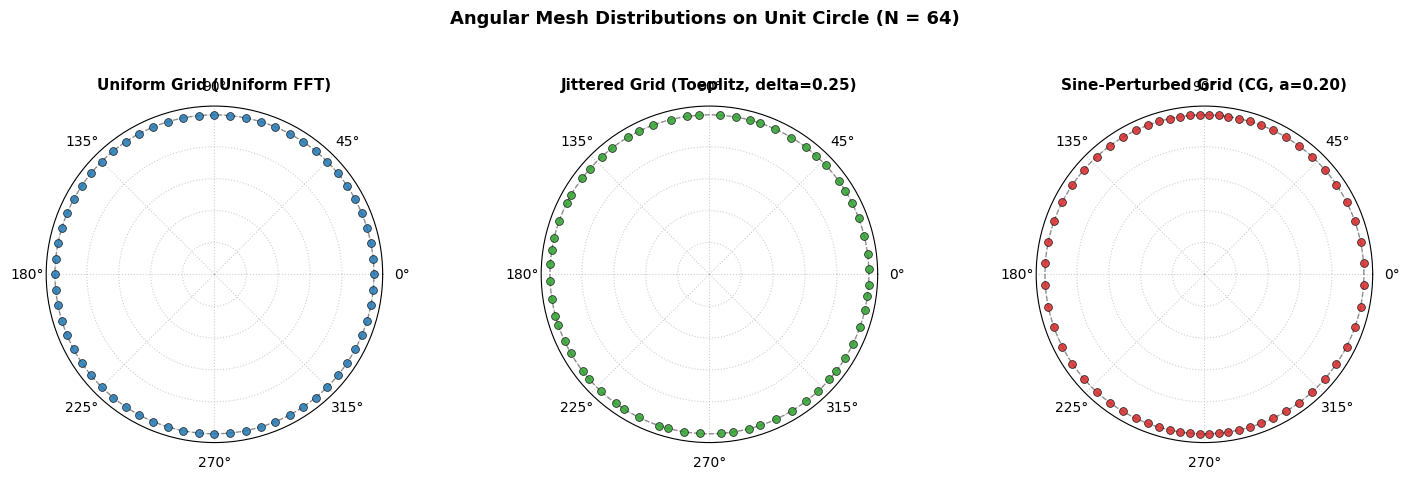

In [3]:
fig_grids = plot_grid_distributions(N=64, R=R)
plt.show()


## 3. Benchmark Execution
Run all 5 methods across the $(N \times M)$ matrix grid.

In [4]:
df_benchmark = run_all_benchmarks(
    N_list=N_LIST,
    M_list=M_LIST,
    problem=problem,
    R=R,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    maxiter_nufft=MAXITER_NUFFT,
    tol_nufft=TOL_NUFFT,
    reg_param=REG_PARAM,
    eps_finufft=EPS_FINUFFT,
    perimeter_only=PERIMETER_ONLY,
    toeplitz_grid="jittered",
    toeplitz_kwargs={"jitter_fraction": 0.25},
    cg_grid="sine_perturbed",
    cg_kwargs={"amplitude": 0.20, "mode": 2},
    use_gpu=USE_GPU
)


Benchmarking 4 Solvers [CPU]:   0%|          | 0/80 [00:00<?, ?it/s]

## 4. Matrix Performance & Accuracy Tables
Formatted $N \times M$ matrix tables in seconds and $L_\infty$ error for each solver configuration.

In [5]:
display_benchmark_tables(df_benchmark, N_values=N_LIST, M_values=M_LIST)



TIMING MATRIX (s) [CPU]


Uniform FFT                                                    \
M           32        64        128       256       512       1024   
N                                                                    
32      0.0012 s  0.0063 s  0.0016 s  0.0022 s  0.0033 s  0.0070 s   
64      0.0100 s         —         —         —         —  0.0097 s   
128     0.0016 s         —         —         —         —  0.0191 s   
256     0.0022 s         —         —         —         —  0.0365 s   
512     0.0033 s         —         —         —         —  0.0892 s   
1024    0.0059 s  0.0134 s  0.0194 s  0.0407 s  0.0829 s  0.2083 s   

     NUDFT (Toeplitz Mesh)                                ... NUFFT Toeplitz  \
M                     32        64        128       256   ...           128    
N                                                         ...                  
32                0.0028 s  0.0031 s  0.1290 s  0.1404 s  ...       0.0280 s   
64                0.0055 s         —         —         —  ...              —   
128               0.1130 s         —         —         —  ...              —   
256               0.1800 s         —         —         —  ...              —   
512               0.3171 s         —         —         —  ...              —   
1024              0.7243 s  1.0170 s  1.5612 s  2.8003 s  ...       0.9150 s   

                                   NUFFT CG (PCGLS)                      \
M         256       512       1024             32        64        128    
N                                                                         
32    0.0475 s  0.5180 s  0.5998 s         0.0377 s  0.0338 s  0.0706 s   
64           —         —  0.7032 s         0.0358 s         —         —   
128          —         —  0.9109 s         0.0268 s         —         —   
256          —         —  1.0141 s         0.0393 s         —         —   
512          —         —  1.4081 s         0.0307 s         —         —   
1024  1.1429 s  1.8932 s  2.5450 s         0.0490 s  0.0540 s  0.0540 s   

                                    
M         256       512       1024  
N                                   
32    0.0962 s  0.0568 s  0.0864 s  
64           —         —  0.1416 s  
128          —         —  0.0708 s  
256          —         —  0.1083 s  
512          —         —  0.1792 s  
1024  0.0891 s  0.1622 s  0.3278 s  

[6 rows x 24 columns]


ACCURACY MATRIX (L_inf Error) [CPU]


Uniform FFT                                                    \
M           32        64        128       256       512       1024   
N                                                                    
32      5.28e-04  1.28e-04  3.15e-05  7.80e-06  1.94e-06  4.85e-07   
64      5.28e-04         —         —         —         —  4.85e-07   
128     5.28e-04         —         —         —         —  4.85e-07   
256     5.28e-04         —         —         —         —  4.85e-07   
512     5.28e-04         —         —         —         —  4.85e-07   
1024    5.28e-04  1.28e-04  3.15e-05  7.80e-06  1.94e-06  4.85e-07   

     NUDFT (Toeplitz Mesh)                                ... NUFFT Toeplitz  \
M                     32        64        128       256   ...           128    
N                                                         ...                  
32                5.28e-04  1.28e-04  3.11e-05  7.79e-06  ...       3.11e-05   
64                5.28e-04         —         —         —  ...              —   
128               5.28e-04         —         —         —  ...              —   
256               5.28e-04         —         —         —  ...              —   
512               5.28e-04         —         —         —  ...              —   
1024              5.28e-04  1.28e-04  3.15e-05  7.80e-06  ...       3.15e-05   

                                   NUFFT CG (PCGLS)                      \
M         256       512       1024             32        64        128    
N                                                                         
32    7.79e-06  1.94e-06  4.84e-07         5.26e-04  1.27e-04  3.13e-05   
64           —         —  4.84e-07         5.28e-04         —         —   
128          —         —  4.86e-07         5.28e-04         —         —   
256          —         —  4.85e-07         5.28e-04         —         —   
512          —         —  4.85e-07         5.28e-04         —         —   
1024  7.80e-06  1.94e-06  4.85e-07         5.28e-04  1.28e-04  3.15e-05   

                                    
M         256       512       1024  
N                                   
32    7.77e-06  1.93e-06  4.83e-07  
64           —         —  5.40e-07  
128          —         —  4.85e-07  
256          —         —  4.85e-07  
512          —         —  4.85e-07  
1024  7.80e-06  1.94e-06  4.85e-07  

[6 rows x 24 columns]

## 5. Consolidated 2x2 Log-Log Runtime Scaling
Comparing execution times (in seconds) across all 5 methods on a single consolidated 2x2 figure.

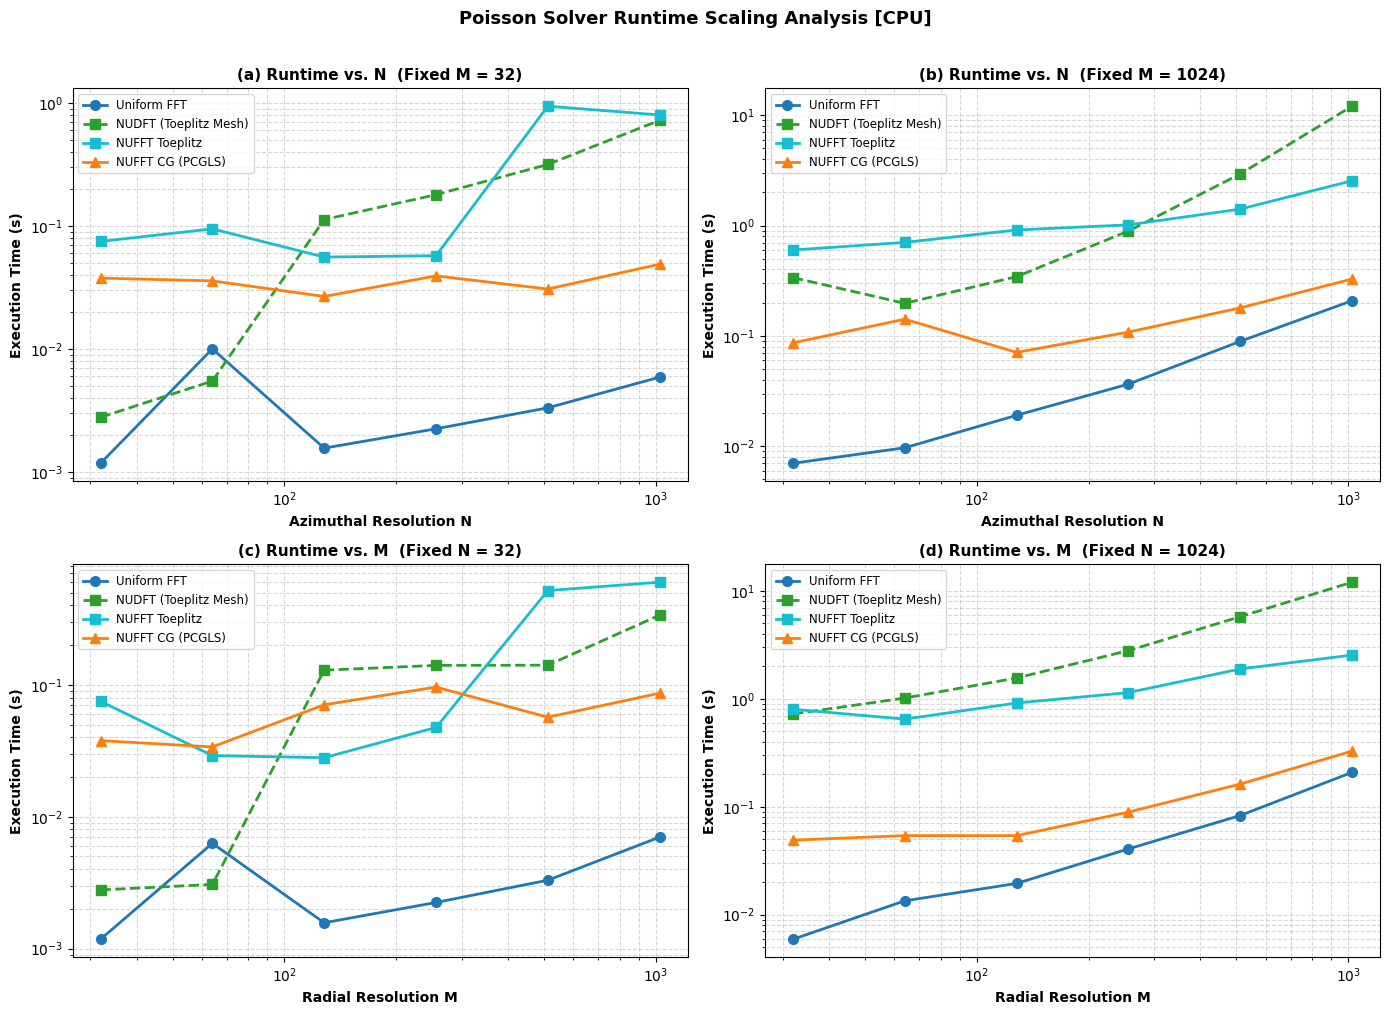

In [6]:
fig_time_2x2 = plot_runtime_2x2(
    df_benchmark,
    N_values=N_LIST,
    M_values=M_LIST,
    use_gpu=USE_GPU,
    title="Poisson Solver Runtime Scaling Analysis"
)
plt.show()


## 6. Consolidated 2x2 Log-Log Accuracy Scaling
Comparing $L_\infty$ error across all 5 methods on a single consolidated 2x2 figure.

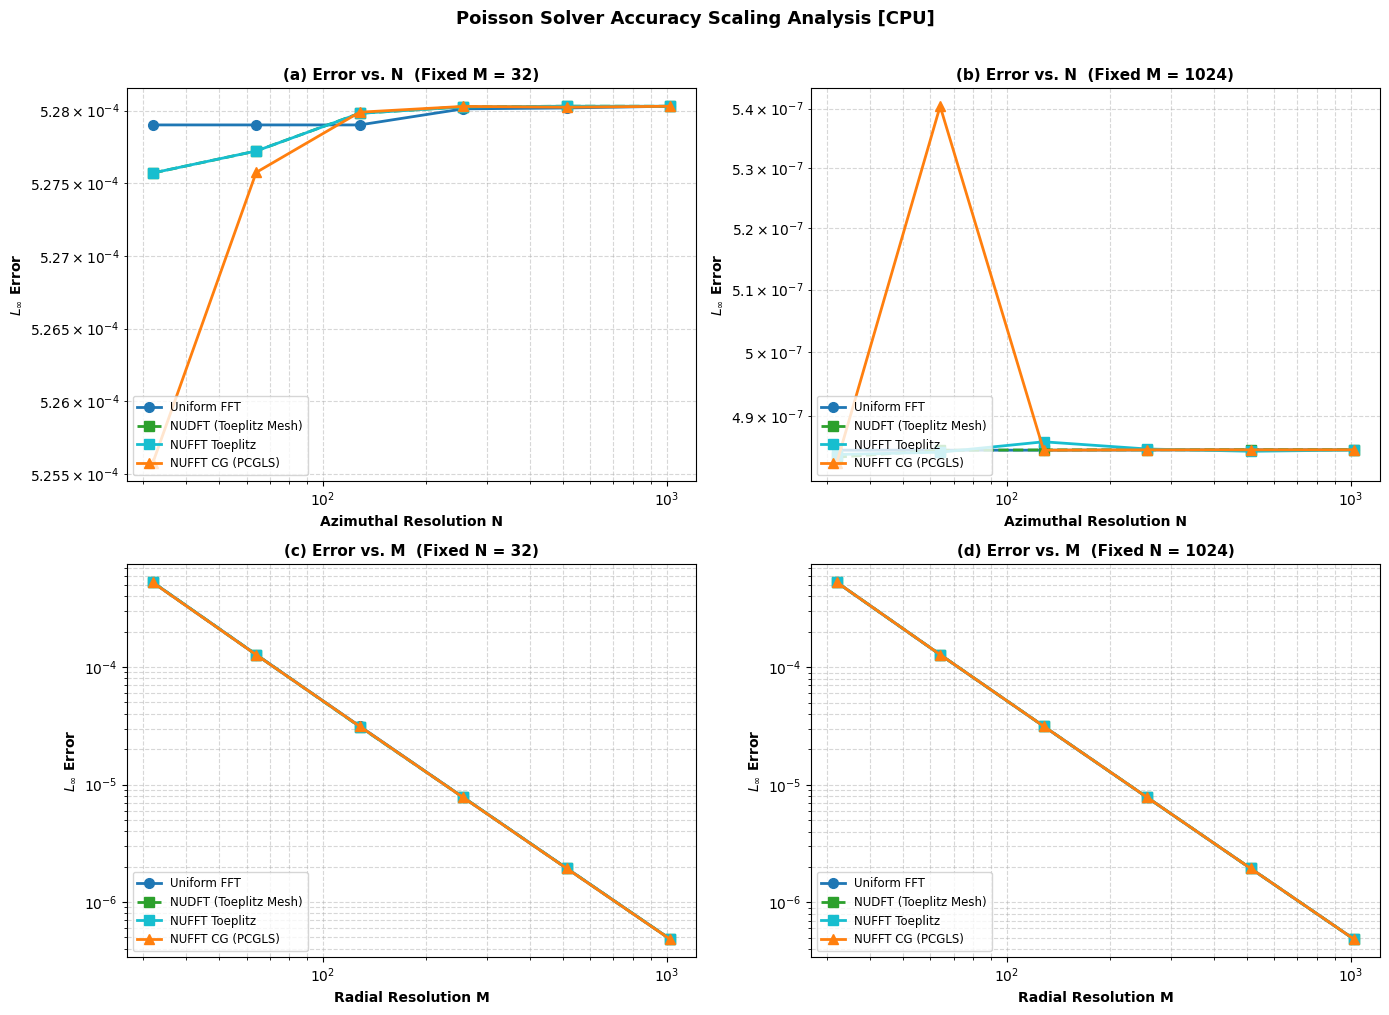

In [7]:
fig_acc_2x2 = plot_accuracy_2x2(
    df_benchmark,
    N_values=N_LIST,
    M_values=M_LIST,
    metric="L_inf_Error",
    use_gpu=USE_GPU,
    title="Poisson Solver Accuracy Scaling Analysis"
)
plt.show()
